# Objective

## Dhaka regularly ranks among the most polluted cities in the world, and fine particulate matter (PM2.5) is the pollutant most closely linked to serious health risks for its residents. The objective of this project is to build a time series model that forecasts hourly PM2.5 concentrations in Dhaka for the next 24 to 72 hours, using recent air quality data and meteorological variables (temperature, humidity, wind speed, and precipitation) from the Open-Meteo APIs. The workflow covers data collection, cleaning, and exploratory analysis of daily and seasonal patterns, followed by a comparison of a seasonal naive baseline against statistical models (SARIMA, Prophet) and machine learning models (XGBoost, LightGBM) with lag and weather features. Models are evaluated with rolling-origin validation to avoid data leakage, and the best one is deployed as a live Streamlit app that refreshes automatically with the latest data, so anyone can see the current air quality and the upcoming forecast.

# Import Necessary Libraries

In [3]:
# Data collection and handling
import requests
import pandas as pd
import numpy as np
import time
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Time series analysis and statistical models
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# Machine learning models and validation
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Saving the model for deployment
import joblib


# API feasibility Test

In [4]:


# # Define the API URL
# url = "https://air-quality-api.open-meteo.com/v1/air-quality"
# params = {
#     "latitude": 23.81,
#     "longitude": 90.41,
#     "hourly": "pm2_5",
#     "start_date": "2022-10-01",
#     "end_date": "2026-10-09",
#     "timezone": "Asia/Dhaka",
# }

# # Fetch data from the API
# response = requests.get(url, params=params, timeout=60)
# response.raise_for_status()
# data = response.json()



# Build DataFrame

In [5]:
# hourly_data = data["hourly"]
# df = pd.DataFrame({
#     "time": hourly_data["time"],
#     "pm2_5": hourly_data["pm2_5"],
# })
# df.head()
# df.to_csv("air_ql.csv")

## Set data formats

In [6]:
df=pd.read_csv("air_ql.csv")
df['time']=pd.to_datetime(df["time"])
df=df.set_index('time')
# Basic checks
print(df.shape)
print(df.index.min(), "->", df.index.max())
print("Frequency:", pd.infer_freq(df.index))
print("Null Values",df.isna().sum())
print(df.describe())

(35280, 2)
2022-10-01 00:00:00 -> 2026-10-09 23:00:00
Frequency: h
Null Values Unnamed: 0    0
pm2_5         0
dtype: int64
         Unnamed: 0         pm2_5
count  35280.000000  35280.000000
mean   17639.500000     48.427406
std    10184.603085     34.271450
min        0.000000      0.400000
25%     8819.750000     22.100000
50%    17639.500000     41.000000
75%    26459.250000     66.600000
max    35279.000000    309.200000


# Explore the Dataset

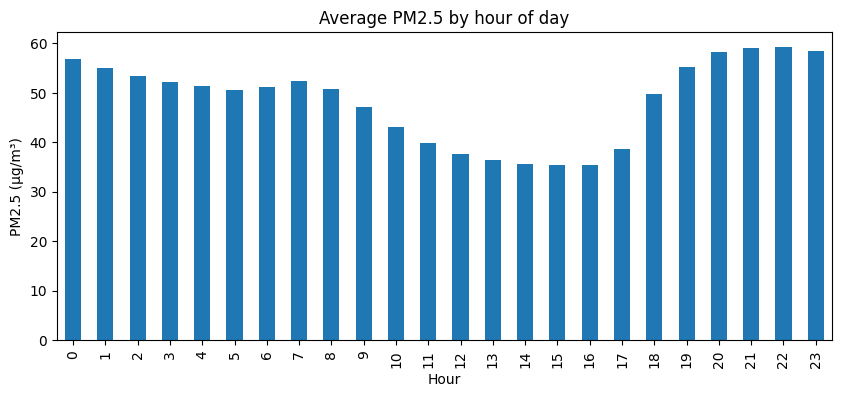

In [7]:
# 5. Average PM2.5 by hour of day
hourly_avg = df.groupby(df.index.hour)["pm2_5"].mean()
hourly_avg.plot(kind="bar", figsize=(10, 4), title="Average PM2.5 by hour of day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

# Check the time window 

In [8]:
def window(h):
    if 5 <= h < 8:   return "Morning"
    if 8 <= h < 11:  return "Office peak"
    if 16 <= h < 20: return "Afternoon peak"
    if h >= 21 or h < 5: return "Night"
    return "Other"

df["window"] = df.index.hour.map(window)
print(df.groupby("window")["pm2_5"].agg(["mean", "std"]))

                     mean        std
window                              
Afternoon peak  44.672670  26.513598
Morning         51.353583  39.700823
Night           55.698588  38.497128
Office peak     47.030748  36.436099
Other           40.470896  25.566271


In [9]:
# Monthly resample
print(df["pm2_5"].resample("MS").mean().round(1))

time
2022-10-01     40.4
2022-11-01     58.6
2022-12-01     73.3
2023-01-01     99.3
2023-02-01     69.8
2023-03-01     61.4
2023-04-01     55.8
2023-05-01     44.5
2023-06-01     31.7
2023-07-01     14.0
2023-08-01     32.4
2023-09-01     25.5
2023-10-01     45.4
2023-11-01     47.2
2023-12-01     48.2
2024-01-01     69.4
2024-02-01     65.7
2024-03-01     55.3
2024-04-01     45.6
2024-05-01     37.6
2024-06-01     29.4
2024-07-01     15.0
2024-08-01     15.4
2024-09-01     25.9
2024-10-01     47.8
2024-11-01     69.3
2024-12-01     83.0
2025-01-01    103.2
2025-02-01     95.9
2025-03-01     60.1
2025-04-01     40.7
2025-05-01     35.9
2025-06-01     28.5
2025-07-01     21.3
2025-08-01     20.7
2025-09-01     27.9
2025-10-01     47.2
2025-11-01     59.0
2025-12-01     68.2
2026-01-01     90.3
2026-02-01     78.1
2026-03-01     63.4
2026-04-01     38.8
2026-05-01     38.3
2026-06-01     35.3
2026-07-01     17.8
2026-08-01     15.8
2026-09-01     29.2
2026-10-01     78.8
Freq: MS, Name:

## Four years is better than two. The seasonal shape holds: January is the peak every year (99, 69, 103, 90), and July and August are the lowest (14 to 32).

- **Winters differ a lot.** The 2023-24 winter was much milder than the others (December 48, January 69), while January 2025 reached 103. A model can't predict a year's winter severity from the calendar, so the model will need to rely on recent PM2.5 levels, as I mentioned before.
  
- **October 2026 (73.7) is still only a few days.** Compare it to full-month figures only after more of the month has passed.

- **The data now has three winters before the most recent one.** You can hold out Dec 2025 to Feb 2026 as a test season and train on everything before it, which is a much harder test than a quiet week in September.


# Visualize the Data

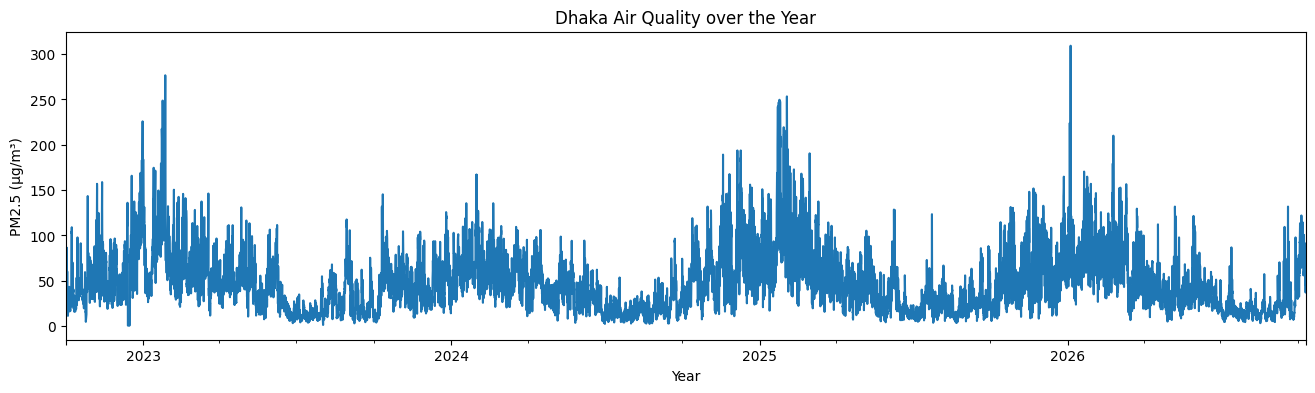

In [10]:
# Year-wise
df['pm2_5'].plot(figsize=(16,4), title="Dhaka Air Quality over the Year")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Year")
plt.show()

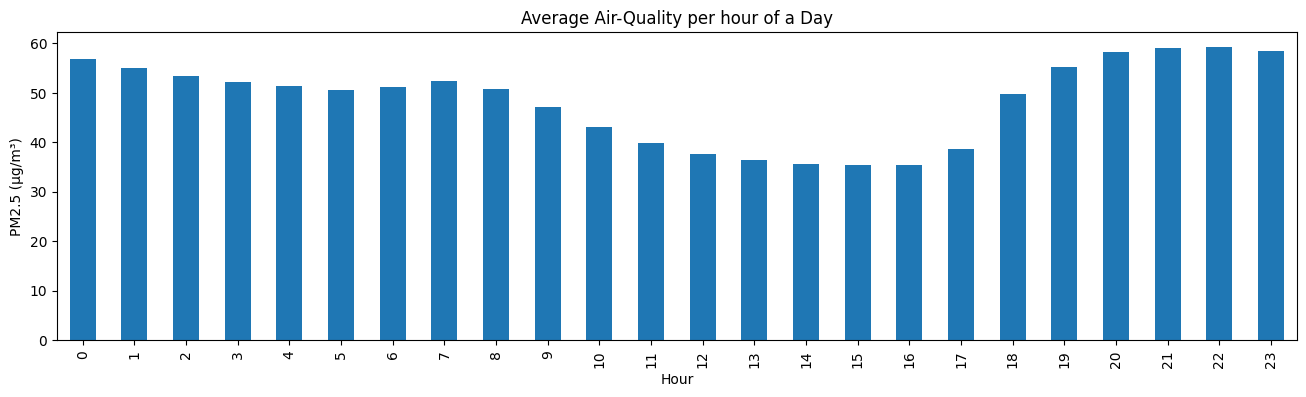

In [11]:
# An average day
hourly_avg= df.groupby(df.index.hour)["pm2_5"].mean()
hourly_avg.plot(figsize=(16,4), kind= "bar", title= "Average Air-Quality per hour of a Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

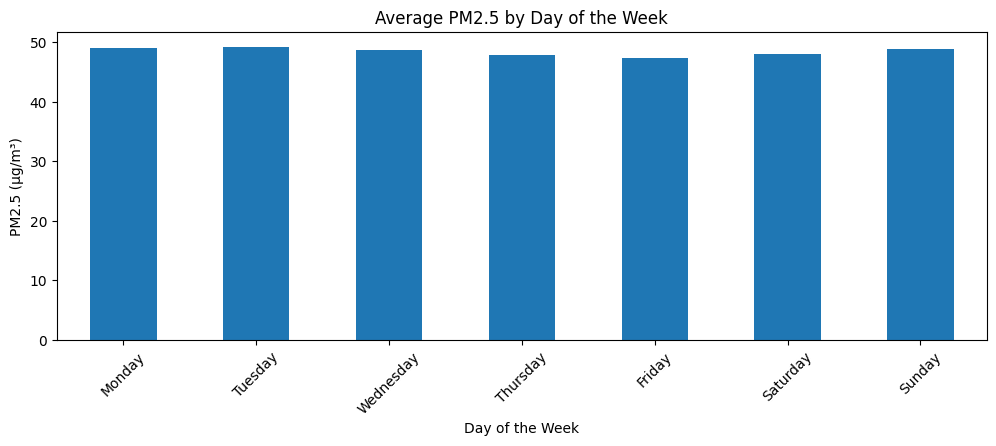

In [12]:
# Average PM2.5 for each day of the week
weekly_avg = df.groupby(df.index.day_name())["pm2_5"].mean()

# Put days in correct order
days_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekly_avg = weekly_avg.reindex(days_order)

# Plot
weekly_avg.plot(
    figsize=(12, 4),
    kind="bar",
    title="Average PM2.5 by Day of the Week"
)

plt.xlabel("Day of the Week")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=45)
plt.show()

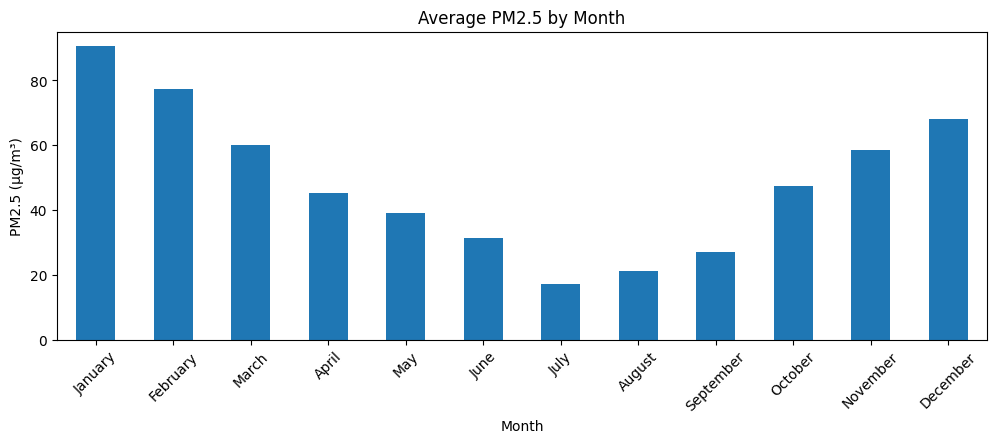

In [13]:
# Average PM2.5 for each month
monthly_avg = df.groupby(df.index.month_name())["pm2_5"].mean()

# Put months in correct chronological order
months_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_avg = monthly_avg.reindex(months_order)

# Plot
monthly_avg.plot(
    figsize=(12, 4),
    kind="bar",
    title="Average PM2.5 by Month"
)

plt.xlabel("Month")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=45)
plt.show()

### Monthly PM2.5 Pattern

- The monthly average PM2.5 shows a clear seasonal pattern. **January has the highest average PM2.5 concentration (around 90 µg/m³)**, followed by February and December. PM2.5 gradually decreases from March through June and reaches its **lowest level in July (around 17 µg/m³)**. Concentrations then increase gradually from August through December.

- Overall, the results indicate that **PM2.5 concentrations are generally higher during the winter months (November–February) and lower during the monsoon/summer period (June–September)**. This strong seasonal pattern suggests that **month or season may be an important feature for the PM2.5 forecasting model**.

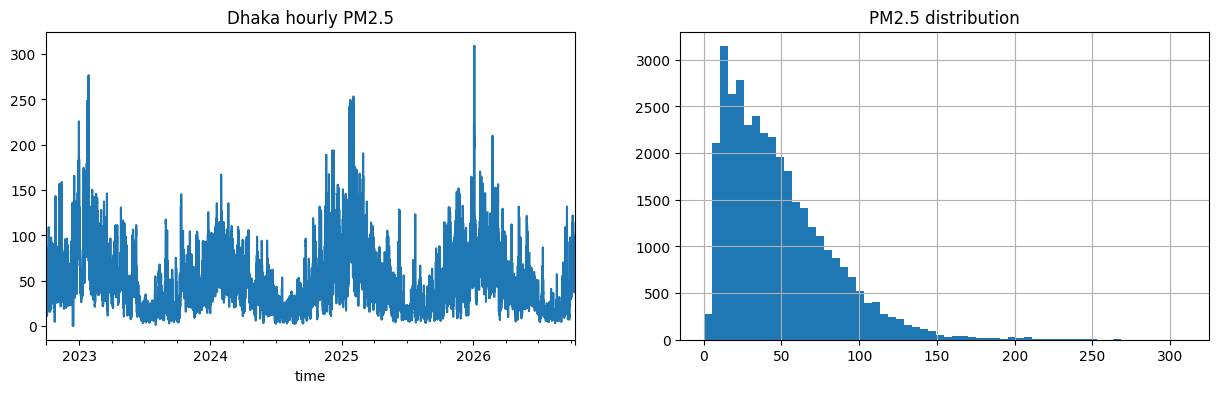

In [14]:
y = df["pm2_5"]

# 1. Full series and distribution
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
y.plot(ax=ax[0], title="Dhaka hourly PM2.5")
y.hist(bins=60, ax=ax[1])
ax[1].set_title("PM2.5 distribution")
plt.show()

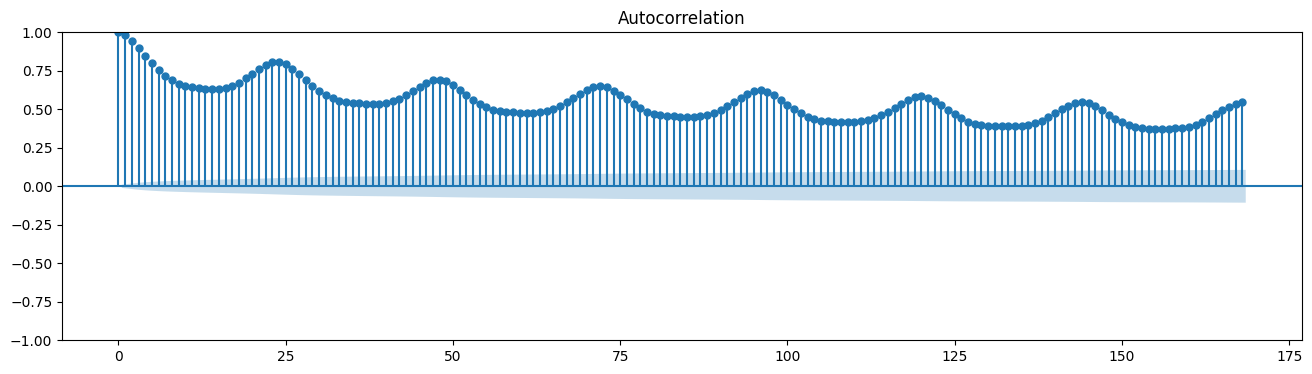

In [15]:
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(figsize=(16, 4))
plot_acf(y, lags=168, ax=ax)
plt.show()

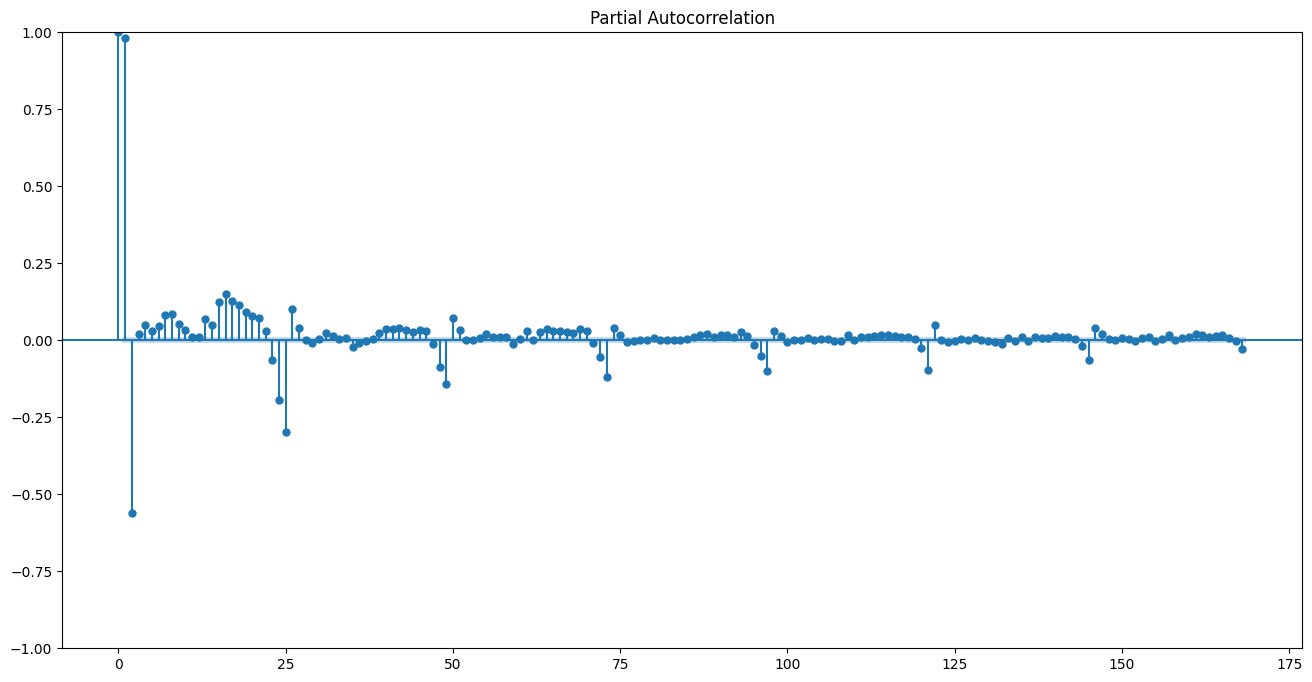

In [16]:
from statsmodels.graphics.tsaplots import plot_pacf
fig, ax = plt.subplots(figsize=(16, 8))
plot_pacf(y, lags=168, ax=ax)
plt.show()

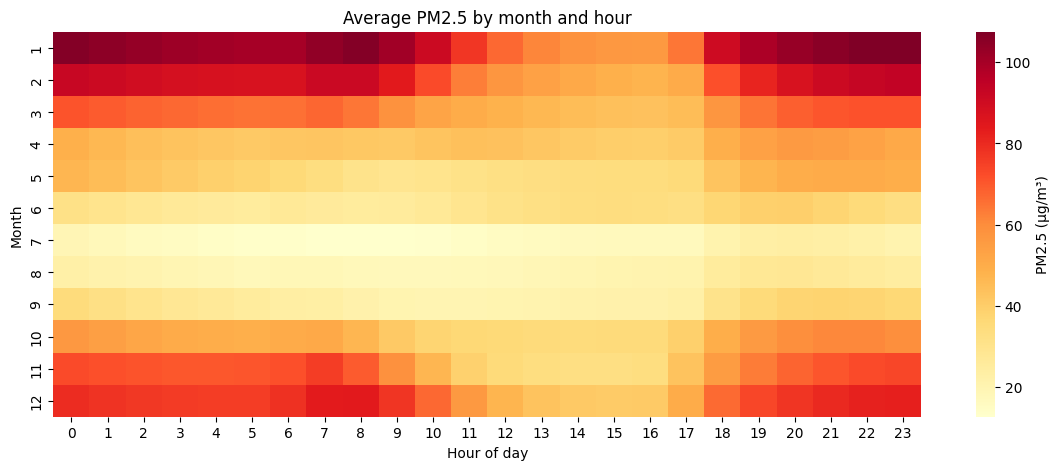

In [17]:
# 3. Hour-of-day by month heatmap
heat = y.groupby([y.index.month, y.index.hour]).mean().unstack()
plt.figure(figsize=(14, 5))
sns.heatmap(heat, cmap="YlOrRd", cbar_kws={"label": "PM2.5 (µg/m³)"})
plt.xlabel("Hour of day")
plt.ylabel("Month")
plt.title("Average PM2.5 by month and hour")
plt.show()

# The Baseline Model

                 season          model   MAE  RMSE  MAE / mean PM2.5
      Winter (Jan 2026)          naive 12.98 16.94             0.175
      Winter (Jan 2026) seasonal_naive 10.91 13.32             0.147
      Spring (Apr 2026)          naive 15.34 22.05             0.337
      Spring (Apr 2026) seasonal_naive 10.67 14.91             0.234
     Monsoon (Jul 2026)          naive 15.66 23.12             0.689
     Monsoon (Jul 2026) seasonal_naive 10.23 15.19             0.450
Post-monsoon (Sep 2026)          naive 39.52 48.98             0.928
Post-monsoon (Sep 2026) seasonal_naive 19.08 27.51             0.448


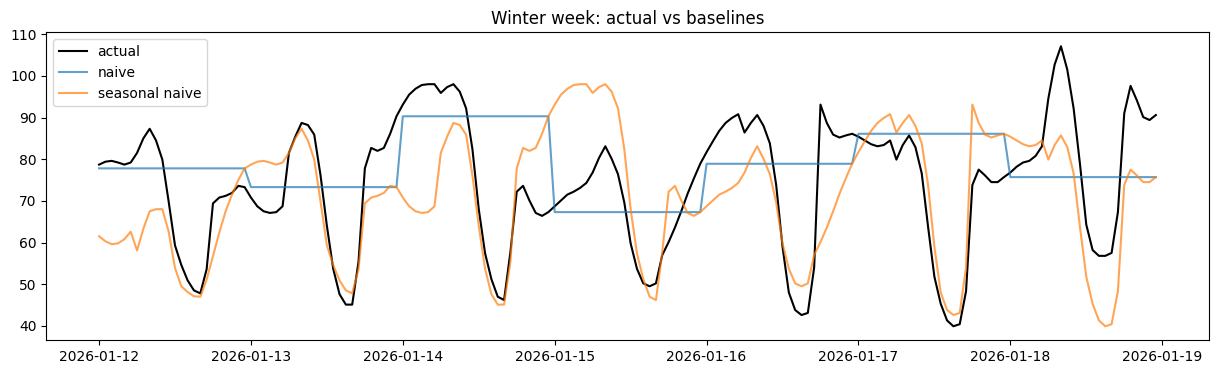

In [18]:
H = 24  # forecast horizon in hours

def naive(y, origin):
    """Repeat the last observed value for the next 24 hours."""
    last = y.loc[:origin - pd.Timedelta(hours=1)].iloc[-1]
    return np.repeat(last, H)

def seasonal_naive(y, origin):
    """Use the previous 24 hours as the forecast for the next 24 hours."""
    return y.loc[origin - pd.Timedelta(hours=24): origin - pd.Timedelta(hours=1)].values

def evaluate(y, origins, fn):
    actual, pred = [], []
    for o in origins:
        actual.append(y.loc[o: o + pd.Timedelta(hours=H - 1)].values)
        pred.append(fn(y, o))
    actual, pred = np.concatenate(actual), np.concatenate(pred)
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    return mae, rmse, mae / actual.mean()

# One test week per season; origins are midnight of each of the 7 days
test_weeks = {
    "Winter (Jan 2026)":      "2026-01-12",
    "Spring (Apr 2026)":      "2026-04-13",
    "Monsoon (Jul 2026)":     "2026-07-13",
    "Post-monsoon (Sep 2026)": "2026-09-14",
}

rows = []
for season, start in test_weeks.items():
    origins = pd.date_range(start, periods=7, freq="D")
    for name, fn in [("naive", naive), ("seasonal_naive", seasonal_naive)]:
        mae, rmse, rel = evaluate(y, origins, fn)
        rows.append({"season": season, "model": name,
                     "MAE": round(mae, 2), "RMSE": round(rmse, 2),
                     "MAE / mean PM2.5": round(rel, 3)})

results = pd.DataFrame(rows)
print(results.to_string(index=False))

# Plot one fold: actual vs both baselines
start = pd.Timestamp(test_weeks["Winter (Jan 2026)"])
origins = pd.date_range(start, periods=7, freq="D")
idx = pd.date_range(start, periods=7 * H, freq="h")
plt.figure(figsize=(15, 4))
plt.plot(idx, y.loc[idx], label="actual", color="black")
plt.plot(idx, np.concatenate([naive(y, o) for o in origins]), label="naive", alpha=0.7)
plt.plot(idx, np.concatenate([seasonal_naive(y, o) for o in origins]), label="seasonal naive", alpha=0.7)
plt.legend()
plt.title("Winter week: actual vs baselines")
plt.show()

Seasonal naive beats naive in all four weeks, so it’s the baseline your real model has to beat.

| Season | Seasonal naive MAE | Relative error |
|---|---:|---:|
| Winter (Jan) | 10.9 | 15% |
| Spring (Apr) | 10.7 | 23% |
| Monsoon (Jul) | 10.2 | 45% |
| Post-monsoon (Sep) | 19.1 | 45% |

## What the table shows

- **Absolute error is almost the same in three seasons (about 10 to 11 µg/m³), so relative error is what differs.** Winter looks best (15%) mostly because the level is high (the mean is about 74), and monsoon looks worst (45%) because the level is low (about 23). I predicted earlier that winter MAE would be much higher in absolute terms, and your data shows that was wrong for this week. Winter’s pattern is stable and repeats from day to day.

- **Sep 2026 is the hard week.** Seasonal naive’s MAE is almost double the others (19.1), and plain naive is at 39.5, with a mean of about 43 for the week. That week sits in the shift from monsoon air to winter air, when the level changes quickly and “same as yesterday” stops working. This is the kind of week where a model that uses weather-driven momentum and recent levels could do better. It’s also a week you’ll likely see in the live app every autumn.

- **Each fold is only one week (7 forecast origins).** Treat the exact numbers as rough. Before you compare models seriously, use several weeks per season, for example 3 to 4 start dates each.